# Exp 17 — EDA supplier views: анализ выхода `06_build_views.py`

**Что смотрим:**
1. Обзор: сколько view-pair датасетов создано, их размеры
2. Schema divergence: насколько сильно переименованы колонки между views
3. Value divergence в позитивных парах (сравнение с baseline из `07_eda_pairs.ipynb`)
4. Примеры позитивных пар — видим переименованные колонки и value-синонимы
5. Итоговое сравнение: baseline vs views

In [1]:
from __future__ import annotations
from pathlib import Path
from itertools import combinations
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path("../..").resolve()
SYNTH = ROOT / "data" / "synthetic"

SOURCES = ["lamoda", "cars_ru", "devices", "auto_ru", "ozon"]
N_VIEWS = 4

def load_dataset(name: str) -> dict | None:
    d = SYNTH / name
    if not d.exists():
        return None
    ta = pd.read_csv(d / "tableA_synth.csv", low_memory=False)
    tb = pd.read_csv(d / "tableB_synth.csv", low_memory=False)
    train = pd.read_csv(d / "train.csv")
    valid = pd.read_csv(d / "valid.csv")
    test  = pd.read_csv(d / "test.csv")
    stats = json.loads((d / "stats.json").read_text()) if (d / "stats.json").exists() else {}
    return {"name": name, "A": ta, "B": tb,
            "train": train, "valid": valid, "test": test, "stats": stats}

# Синтетические view-pair датасеты: <name>_v{i}v{j}
synth_view_names = [
    f"{src}_v{i}v{j}"
    for src in ["lamoda", "cars_ru", "devices"]
    for i, j in combinations(range(N_VIEWS), 2)
]
# Датасеты с natural labels + synonyms: <name>_syn{k}
natural_view_names = [
    f"{src}_syn{k}"
    for src in ["auto_ru", "ozon"]
    for k in range(N_VIEWS)
]
# Baseline (из 04_synth_pairs)
baseline_names = SOURCES

all_view_names = synth_view_names + natural_view_names
view_dsets = {n: ds for n in all_view_names if (ds := load_dataset(n)) is not None}
base_dsets = {n: ds for n in baseline_names if (ds := load_dataset(n)) is not None}

print(f"View-pair датасеты: {len(view_dsets)}/{len(all_view_names)} найдено")
print(f"  Синтетические: {[n for n in synth_view_names if n in view_dsets]}")
print(f"  Natural views: {[n for n in natural_view_names if n in view_dsets]}")
print(f"Baseline датасеты: {list(base_dsets.keys())}")

View-pair датасеты: 26/26 найдено
  Синтетические: ['lamoda_v0v1', 'lamoda_v0v2', 'lamoda_v0v3', 'lamoda_v1v2', 'lamoda_v1v3', 'lamoda_v2v3', 'cars_ru_v0v1', 'cars_ru_v0v2', 'cars_ru_v0v3', 'cars_ru_v1v2', 'cars_ru_v1v3', 'cars_ru_v2v3', 'devices_v0v1', 'devices_v0v2', 'devices_v0v3', 'devices_v1v2', 'devices_v1v3', 'devices_v2v3']
  Natural views: ['auto_ru_syn0', 'auto_ru_syn1', 'auto_ru_syn2', 'auto_ru_syn3', 'ozon_syn0', 'ozon_syn1', 'ozon_syn2', 'ozon_syn3']
Baseline датасеты: ['lamoda', 'cars_ru', 'devices', 'auto_ru', 'ozon']


---
## 1. Обзор view-pair датасетов

In [2]:
rows = []
for name, ds in view_dsets.items():
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    n_pos = int(labeled["label"].sum())
    n_neg = len(labeled) - n_pos
    cols_a = [c for c in ds["A"].columns if c != "id"]
    cols_b = [c for c in ds["B"].columns if c != "id"]
    shared = len(set(cols_a) & set(cols_b))
    src = name.split("_v")[0].split("_syn")[0]
    rows.append({
        "датасет": name,
        "источник": src,
        "строк A": len(ds["A"]),
        "кол A": len(cols_a),
        "кол B": len(cols_b),
        "общих": shared,
        "Jaccard": round(shared / len(set(cols_a) | set(cols_b)), 2) if cols_a or cols_b else 0,
        "позитивов": n_pos,
        "негативов": n_neg,
    })

ov = pd.DataFrame(rows).set_index("датасет")
display(ov)

,источник,строк A,кол A,кол B,общих,Jaccard,позитивов,негативов
датасет,,,,,,,,
lamoda_v0v1,lamoda,10317,40,40,3,0.04,10317,51585
lamoda_v0v2,lamoda,10317,40,40,7,0.10,10317,51585
lamoda_v0v3,lamoda,10317,40,39,5,0.07,10317,51585
lamoda_v1v2,lamoda,10317,40,40,4,0.05,10317,51585
lamoda_v1v3,lamoda,10317,40,39,7,0.10,10317,51585
lamoda_v2v3,lamoda,10317,40,39,6,0.08,10317,51585
cars_ru_v0v1,cars_ru,100000,169,169,30,0.10,100000,500000
cars_ru_v0v2,cars_ru,100000,169,169,34,0.11,100000,500000
cars_ru_v0v3,cars_ru,100000,169,168,34,0.11,100000,500000


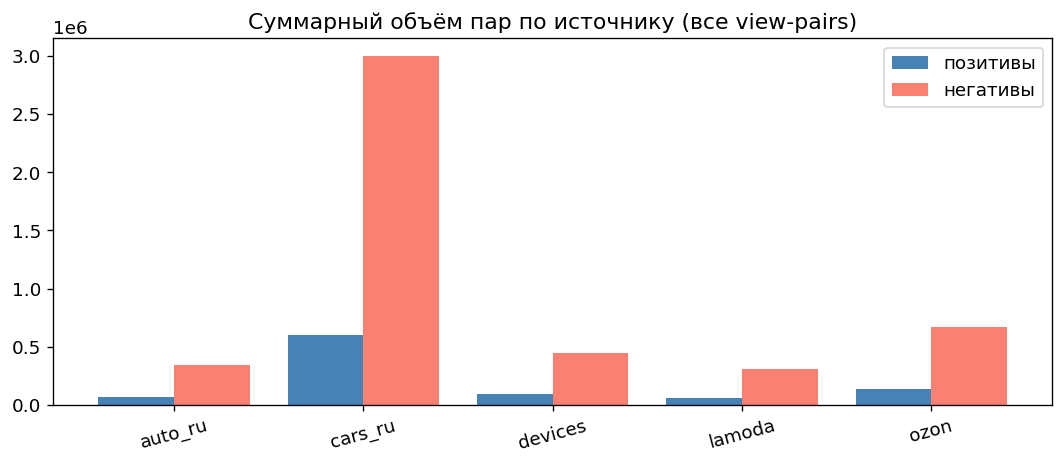

In [3]:
# Суммарный объём по источникам
if not ov.empty:
    src_total = ov.groupby("источник")[["позитивов", "негативов"]].sum()
    x = np.arange(len(src_total))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - 0.2, src_total["позитивов"], 0.4, label="позитивы", color="steelblue")
    ax.bar(x + 0.2, src_total["негативов"], 0.4, label="негативы", color="salmon")
    ax.set_xticks(x)
    ax.set_xticklabels(src_total.index, rotation=15)
    ax.set_title("Суммарный объём пар по источнику (все view-pairs)")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 2. Schema divergence: насколько переименованы колонки

Для каждого источника сравниваем колонки разных views между собой.
Jaccard ≪ 1.0 означает хорошее переименование — модель не может тривиально найти матч по имени.

In [4]:
def col_jaccard(cols_a: set, cols_b: set) -> float:
    if not cols_a and not cols_b:
        return 1.0
    return len(cols_a & cols_b) / len(cols_a | cols_b)

# Для синтетических: читаем N views и смотрим попарный Jaccard колонок
print("Schema Jaccard между views одного источника:")
print(f"(1.0 = идентичные схемы, 0.0 = нет общих колонок)\n")

for src in ["lamoda", "cars_ru", "devices"]:
    # Берём tableA из каждой v{i}v{j} пары, чтобы восстановить схему view_i
    # tableA датасета v0v1 = view_0; tableB = view_1 и т.д.
    views_cols: dict[int, set] = {}
    for i, j in combinations(range(N_VIEWS), 2):
        name = f"{src}_v{i}v{j}"
        if name not in view_dsets:
            continue
        ds = view_dsets[name]
        views_cols[i] = set(c for c in ds["A"].columns if c != "id")
        views_cols[j] = set(c for c in ds["B"].columns if c != "id")

    if not views_cols:
        print(f"  {src}: нет данных")
        continue

    jaccards = []
    for vi, vj in combinations(sorted(views_cols.keys()), 2):
        j = col_jaccard(views_cols[vi], views_cols[vj])
        jaccards.append(j)

    print(f"  {src}: Jaccard min={min(jaccards):.2f} mean={np.mean(jaccards):.2f} max={max(jaccards):.2f}")
    for vi, vj in combinations(sorted(views_cols.keys()), 2):
        j = col_jaccard(views_cols[vi], views_cols[vj])
        print(f"    view{vi} vs view{vj}: {j:.2f}")
    print()

Schema Jaccard между views одного источника:
(1.0 = идентичные схемы, 0.0 = нет общих колонок)

  lamoda: Jaccard min=0.04 mean=0.07 max=0.10
    view0 vs view1: 0.04
    view0 vs view2: 0.10
    view0 vs view3: 0.07
    view1 vs view2: 0.05
    view1 vs view3: 0.10
    view2 vs view3: 0.08

  cars_ru: Jaccard min=0.08 mean=0.10 max=0.13
    view0 vs view1: 0.10
    view0 vs view2: 0.11
    view0 vs view3: 0.11
    view1 vs view2: 0.13
    view1 vs view3: 0.09
    view2 vs view3: 0.08

  devices: Jaccard min=0.08 mean=0.12 max=0.17
    view0 vs view1: 0.17
    view0 vs view2: 0.12
    view0 vs view3: 0.08
    view1 vs view2: 0.12
    view1 vs view3: 0.12
    view2 vs view3: 0.12



In [5]:
# Для natural views — Jaccard колонок между syn{k} парами
print("Schema Jaccard (natural views):")
for src in ["auto_ru", "ozon"]:
    col_sets_a = []
    col_sets_b = []
    for k in range(N_VIEWS):
        name = f"{src}_syn{k}"
        if name not in view_dsets:
            continue
        ds = view_dsets[name]
        col_sets_a.append(set(c for c in ds["A"].columns if c != "id"))
        col_sets_b.append(set(c for c in ds["B"].columns if c != "id"))

    if not col_sets_a:
        print(f"  {src}: нет данных")
        continue

    # Jaccard между syn0 и остальными (A-сторона)
    jacs_a = [col_jaccard(col_sets_a[0], col_sets_a[k]) for k in range(1, len(col_sets_a))]
    jacs_b = [col_jaccard(col_sets_b[0], col_sets_b[k]) for k in range(1, len(col_sets_b))]
    if jacs_a:
        print(f"  {src} (сторона A): Jaccard vs syn0 — {[round(j,2) for j in jacs_a]}")
    if jacs_b:
        print(f"  {src} (сторона B): Jaccard vs syn0 — {[round(j,2) for j in jacs_b]}")

Schema Jaccard (natural views):
  auto_ru (сторона A): Jaccard vs syn0 — [0.11, 0.08, 0.11]
  auto_ru (сторона B): Jaccard vs syn0 — [0.1, 0.11, 0.1]
  ozon (сторона A): Jaccard vs syn0 — [0.18, 0.11, 0.11]
  ozon (сторона B): Jaccard vs syn0 — [0.33, 0.11, 0.05]


---
## 3. Value divergence: baseline vs views

Главный вопрос: улучшили ли synonym-views divergence для synthetic датасетов?
`lamoda` и `devices` были ⚠ trivial с `median_div ≈ 0`.

In [6]:
def value_divergence(ds: dict, n_sample: int = 400) -> pd.Series:
    """Доля общих ячеек с разными значениями в позитивных парах."""
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    pos = labeled[labeled["label"] == 1].head(n_sample)
    ta = ds["A"].set_index("id")
    tb = ds["B"].set_index("id")
    shared_cols = [c for c in ta.columns if c in tb.columns]
    if not shared_cols:
        return pd.Series([], dtype=float)
    divs = []
    for _, row in pos.iterrows():
        a_id, b_id = int(row["ltable_id"]), int(row["rtable_id"])
        if a_id not in ta.index or b_id not in tb.index:
            continue
        ra = ta.loc[a_id, shared_cols].astype(str)
        rb = tb.loc[b_id, shared_cols].astype(str)
        mask = (ra != "nan") | (rb != "nan")
        if mask.sum() == 0:
            continue
        divs.append((ra[mask] != rb[mask]).mean())
    return pd.Series(divs)


# Baseline
baseline_div = {}
for name, ds in base_dsets.items():
    d = value_divergence(ds)
    baseline_div[name] = d.median() if not d.empty else float("nan")

# Views: берём медиану по всем view-парам одного источника
view_div: dict[str, list] = {}
for name, ds in view_dsets.items():
    src = name.split("_v")[0].split("_syn")[0]
    d = value_divergence(ds)
    if not d.empty:
        view_div.setdefault(src, []).append(d.median())

# Таблица сравнения
cmp_rows = []
for src in SOURCES:
    base_md = baseline_div.get(src, float("nan"))
    view_mds = view_div.get(src, [])
    view_md = np.median(view_mds) if view_mds else float("nan")
    delta = view_md - base_md if not np.isnan(view_md) and not np.isnan(base_md) else float("nan")
    cmp_rows.append({
        "источник": src,
        "baseline median_div": round(base_md, 2) if not np.isnan(base_md) else "—",
        "views median_div": round(view_md, 2) if not np.isnan(view_md) else "—",
        "Δ": f"+{delta:.2f}" if delta > 0 else (f"{delta:.2f}" if not np.isnan(delta) else "—"),
        "оценка": (
            "✓ улучшено" if not np.isnan(view_md) and view_md >= 0.05
            else "⚠ всё ещё trivial" if not np.isnan(view_md)
            else "— нет данных"
        ),
    })

cmp = pd.DataFrame(cmp_rows).set_index("источник")
display(cmp)

,baseline median_div,views median_div,Δ,оценка
источник,,,,
lamoda,0.00,0.25,+0.25,✓ улучшено
cars_ru,0.01,0.33,+0.32,✓ улучшено
devices,0.00,0.00,0.00,⚠ всё ещё trivial
auto_ru,0.03,0.33,+0.30,✓ улучшено
ozon,0.25,0.25,0.00,✓ улучшено


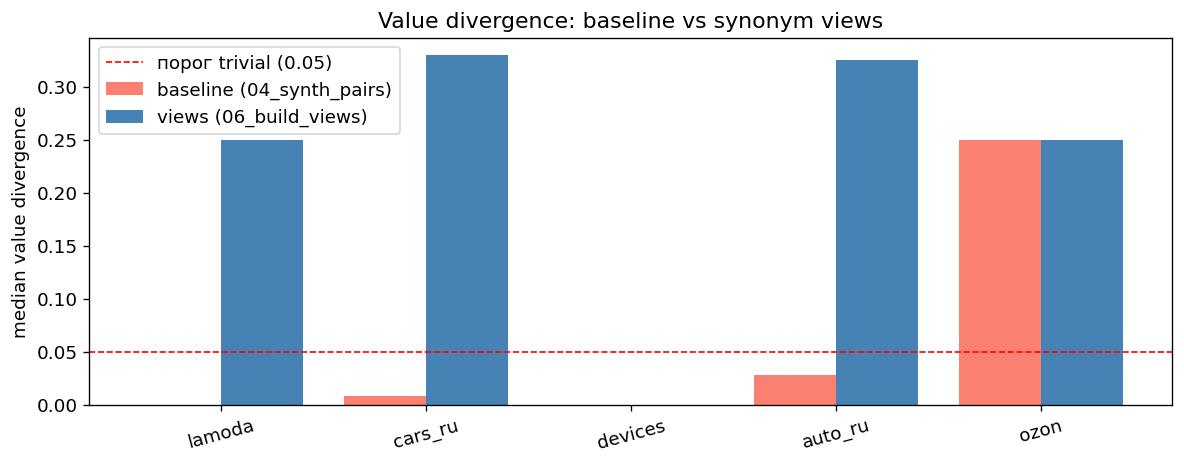

In [7]:
# График: baseline vs views
sources_plot = [s for s in SOURCES if s in baseline_div or s in view_div]
if sources_plot:
    x = np.arange(len(sources_plot))
    base_vals = [baseline_div.get(s, 0) for s in sources_plot]
    view_vals  = [np.median(view_div[s]) if s in view_div and view_div[s] else 0 for s in sources_plot]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - 0.2, base_vals, 0.4, label="baseline (04_synth_pairs)", color="salmon")
    ax.bar(x + 0.2, view_vals,  0.4, label="views (06_build_views)",    color="steelblue")
    ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="порог trivial (0.05)")
    ax.set_xticks(x); ax.set_xticklabels(sources_plot, rotation=15)
    ax.set_ylabel("median value divergence")
    ax.set_title("Value divergence: baseline vs synonym views")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 4. Примеры позитивных пар из view-датасетов

Смотрим: переименованы ли колонки, заменены ли значения на синонимы.

In [8]:
def show_view_pair(ds: dict, n: int = 2) -> None:
    name = ds["name"]
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    pos = labeled[labeled["label"] == 1].head(n)

    ta = ds["A"].set_index("id")
    tb = ds["B"].set_index("id")

    cols_a = [c for c in ta.columns]
    cols_b = [c for c in tb.columns]
    shared = [c for c in cols_a if c in cols_b]
    only_a = [c for c in cols_a if c not in cols_b][:4]
    only_b = [c for c in cols_b if c not in cols_a][:4]

    print(f"\n{'='*65}")
    print(f"{name.upper()}")
    print(f"  Только в A: {only_a}")
    print(f"  Только в B: {only_b}")
    print(f"  Общих: {len(shared)}/{len(cols_a)} (A), {len(shared)}/{len(cols_b)} (B)")
    print(f"{'='*65}")

    show_cols_a = [c for c in shared[:6]]
    for i, (_, row) in enumerate(pos.iterrows()):
        a_id = int(row["ltable_id"])
        b_id = int(row["rtable_id"])
        if a_id not in ta.index or b_id not in tb.index:
            continue
        ra = ta.loc[a_id, show_cols_a].astype(str)
        rb = tb.loc[b_id, show_cols_a].astype(str)
        pair_df = pd.DataFrame({"A": ra, "B": rb})
        pair_df["≠"] = [
            "✗" if str(a) != str(b) and str(a) != "nan" and str(b) != "nan" else ""
            for a, b in zip(ra, rb)
        ]
        print(f"\n  Пара {i+1} (A={a_id}, B={b_id})")
        print(pair_df.to_string())


# Один пример для каждого источника
shown = set()
for src in ["lamoda", "cars_ru", "devices", "auto_ru", "ozon"]:
    for name, ds in view_dsets.items():
        if name.startswith(src + "_") and src not in shown:
            show_view_pair(ds, n=2)
            shown.add(src)
            break


LAMODA_V0V1
  Только в A: ['price_value', 'Картинка', 'about.Состав, %', 'about.Сезон']
  Только в B: ['Brand', 'Price', 'image_url', 'Пропорции']
  Общих: 3/40 (A), 3/40 (B)

  Пара 1 (A=7566, B=7566)
                                 A               B ≠
Title               Куртка кожаная  Куртка кожаная  
Рост и вес                80-60-87        80-60-87  
Место производства             nan             nan  

  Пара 2 (A=3674, B=3674)
                                                  A                                B ≠
Title               Брюки спортивные 3-STRIPES PANT  Брюки спортивные 3-STRIPES PANT  
Рост и вес                             89 - 72 - 91                     89 - 72 - 91  
Место производства                              nan                              nan  

CARS_RU_V0V1
  Только в A: ['марка', 'car_model', 'генерация', 'configuration']
  Только в B: ['mark', 'model_gen', 'версия', 'набор']
  Общих: 30/169 (A), 30/169 (B)

  Пара 1 (A=16075, B=16075)
             

---
## 5. Распределение Jaccard между A и B внутри view-датасетов

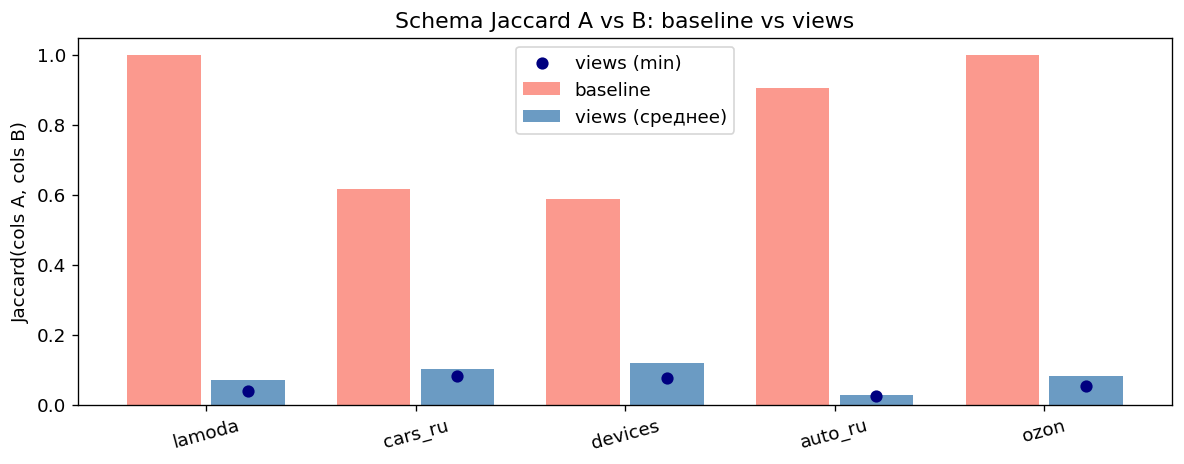

In [9]:
# Для каждого источника: Jaccard(cols_A, cols_B) в каждой view-паре
src_jaccards: dict[str, list] = {}
for name, ds in view_dsets.items():
    src = name.split("_v")[0].split("_syn")[0]
    ca = set(c for c in ds["A"].columns if c != "id")
    cb = set(c for c in ds["B"].columns if c != "id")
    j = len(ca & cb) / len(ca | cb) if ca | cb else 1.0
    src_jaccards.setdefault(src, []).append(j)

# Также baseline Jaccard
base_jaccards = {}
for name, ds in base_dsets.items():
    ca = set(c for c in ds["A"].columns if c != "id")
    cb = set(c for c in ds["B"].columns if c != "id")
    base_jaccards[name] = len(ca & cb) / len(ca | cb) if ca | cb else 1.0

srcs_all = [s for s in SOURCES if s in src_jaccards or s in base_jaccards]
if srcs_all:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(srcs_all))
    view_means = [np.mean(src_jaccards.get(s, [0])) for s in srcs_all]
    view_mins  = [min(src_jaccards.get(s, [0]))     for s in srcs_all]
    base_vals  = [base_jaccards.get(s, 0)           for s in srcs_all]

    ax.bar(x - 0.2, base_vals,  0.35, label="baseline",       color="salmon",    alpha=0.8)
    ax.bar(x + 0.2, view_means, 0.35, label="views (среднее)", color="steelblue", alpha=0.8)
    ax.scatter(x + 0.2, view_mins, color="navy", zorder=5, s=40, label="views (min)")
    ax.set_xticks(x); ax.set_xticklabels(srcs_all, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Jaccard(cols A, cols B)")
    ax.set_title("Schema Jaccard A vs B: baseline vs views")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 6. Итог — сводная таблица

In [10]:
final_rows = []
for src in SOURCES:
    view_names_src = [n for n in view_dsets if n.startswith(src + "_")]
    if not view_names_src:
        final_rows.append({"источник": src, "статус": "❌ нет данных"})
        continue

    # Суммарные позитивы во всех view-парах
    total_pos = sum(
        int(pd.concat([view_dsets[n]["train"], view_dsets[n]["valid"], view_dsets[n]["test"]])["label"].sum())
        for n in view_names_src
    )

    base_md = baseline_div.get(src, float("nan"))
    view_md = np.median(view_div.get(src, [float("nan")]))
    jac_mean = np.mean(src_jaccards.get(src, [float("nan")]))

    status = (
        "✓ OK" if not np.isnan(view_md) and view_md >= 0.05
        else "⚠ trivial"
    )

    final_rows.append({
        "источник": src,
        "датасетов": len(view_names_src),
        "суммарно позитивов": total_pos,
        "baseline div": round(base_md, 2) if not np.isnan(base_md) else "—",
        "views div": round(view_md, 2) if not np.isnan(view_md) else "—",
        "Jaccard A/B (mean)": round(jac_mean, 2) if not np.isnan(jac_mean) else "—",
        "статус": status,
    })

final = pd.DataFrame(final_rows).set_index("источник")
display(final)
print("\n'views div' = медиана value_divergence по всем C(4,2)=6 парам views.")
print("Хорошо если views div >> baseline div → синонимы добавили разнообразие.")

,датасетов,суммарно позитивов,baseline div,views div,Jaccard A/B (mean),статус
источник,,,,,,
lamoda,6,61902,0.00,0.25,0.07,✓ OK
cars_ru,6,600000,0.01,0.33,0.10,✓ OK
devices,6,90000,0.00,0.00,0.12,⚠ trivial
auto_ru,4,67820,0.03,0.33,0.03,✓ OK
ozon,4,133656,0.25,0.25,0.08,✓ OK



'views div' = медиана value_divergence по всем C(4,2)=6 парам views.
Хорошо если views div >> baseline div → синонимы добавили разнообразие.
